In [5]:
import pandas as pd
import numpy as np
from scipy.stats import truncnorm

# Set random seed for reproducibility
np.random.seed(42)

def generate_synthetic_data(n_patients=10000):
    """
    Generates a synthetic dataset of T2DM patients in UK Primary Care.
    Distributions are approximated based on UK general practice profiles.
    Updated weights to ensure a stronger clinical signal for ML performance.
    """
    print(f"Generating synthetic data for {n_patients} patients...")
    
    # --- 1. Demographics ---
    age = np.random.normal(loc=65, scale=12, size=n_patients)
    age = np.clip(age, 30, 95).astype(int)
    
    sex = np.random.choice(['Male', 'Female'], size=n_patients, p=[0.55, 0.45])
    
    ethnicity = np.random.choice(
        ['White', 'Asian', 'Black', 'Other'], 
        size=n_patients, 
        p=[0.75, 0.12, 0.08, 0.05]
    )

    # --- 2. Clinical Biometrics ---
    bmi = np.random.normal(loc=31, scale=6, size=n_patients)
    bmi = np.clip(bmi, 18.5, 55)

    hba1c = np.random.gamma(shape=10, scale=6, size=n_patients)
    hba1c = np.clip(hba1c, 35, 110) 

    sbp = np.random.normal(loc=135, scale=15, size=n_patients)
    
    ldl = np.random.normal(loc=3.0, scale=0.8, size=n_patients)

    # --- 3. Lifestyle & History ---
    smoking = np.random.choice(['Non-Smoker', 'Ex-Smoker', 'Current Smoker'], size=n_patients, p=[0.5, 0.3, 0.2])
    
    duration = np.random.exponential(scale=8, size=n_patients)
    duration = np.clip(duration, 0, 40)

    # --- 4. Complication Logic (Updated for stronger signal) ---
    # Coefficients adjusted to ensure the model can achieve AUROC > 0.80
    log_odds = -6.5 
    
    log_odds += (age - 50) * 0.05           
    log_odds += (hba1c - 42) * 0.08         # Major Driver: Glycaemic control
    log_odds += (bmi - 25) * 0.04           
    log_odds += (sbp - 120) * 0.03          
    log_odds += (duration) * 0.12           # Major Driver: Time exposure
    
    log_odds += np.where(sex == 'Male', 0.3, 0)
    log_odds += np.where(smoking == 'Current Smoker', 0.9, 0)
    
    # Convert log odds to probability
    probability = 1 / (1 + np.exp(-log_odds))
    
    # Binary outcome based on probability
    complication_event = (np.random.random(n_patients) < probability).astype(int)

    df = pd.DataFrame({
        'Patient_ID': range(100000, 100000 + n_patients),
        'Age': age,
        'Sex': sex,
        'Ethnicity': ethnicity,
        'BMI': np.round(bmi, 1),
        'HbA1c_mmol': np.round(hba1c, 1),
        'Systolic_BP': np.round(sbp, 0).astype(int),
        'LDL_Cholesterol': np.round(ldl, 1),
        'Smoking_Status': smoking,
        'Diabetes_Duration_Years': np.round(duration, 1),
        'Risk_Probability_True': np.round(probability, 4),
        'Target_Complication_Flag': complication_event
    })

    return df

if __name__ == "__main__":
    df = generate_synthetic_data()
    filename = "t2dm_synthetic_data.csv"
    df.to_csv(filename, index=False)
    print(f"Success! Dataset saved to {filename}")
    print(f"Complication Rate: {df['Target_Complication_Flag'].mean():.2%}")

Generating synthetic data for 10000 patients...
Success! Dataset saved to t2dm_synthetic_data.csv
Complication Rate: 18.61%


In [6]:
!pip install xgboost shap

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report
import xgboost as xgb
import shap
import warnings
import joblib



# Suppress the specific SHAP/NumPy seed warning to keep output clean
warnings.filterwarnings("ignore", message="The NumPy global RNG was seeded")

# 1. Load Data
try:
    df = pd.read_csv("t2dm_synthetic_data.csv")
except FileNotFoundError:
    print("Error: 't2dm_synthetic_data.csv' not found. Please run 'generate_data.py' first.")
    exit()

X = df.drop(['Patient_ID', 'Risk_Probability_True', 'Target_Complication_Flag'], axis=1)
y = df['Target_Complication_Flag']

# 2. Preprocessing
cat_cols = ['Sex', 'Ethnicity', 'Smoking_Status']
num_cols = ['Age', 'BMI', 'HbA1c_mmol', 'Systolic_BP', 'LDL_Cholesterol', 'Diabetes_Duration_Years']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(drop='first'), cat_cols)
    ])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [8]:
# 3. Models
challenger_lr = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', LogisticRegression())])
champion_xgb = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', xgb.XGBClassifier(n_estimators=100, max_depth=4, eval_metric='logloss', random_state=42))])

# 4. Train
print("Training models...")
challenger_lr.fit(X_train, y_train)
champion_xgb.fit(X_train, y_train)

# 5. Metrics Calculation
lr_probs = challenger_lr.predict_proba(X_test)[:, 1]
xgb_probs = champion_xgb.predict_proba(X_test)[:, 1]

lr_auc = roc_auc_score(y_test, lr_probs)
xgb_auc = roc_auc_score(y_test, xgb_probs)

print("-" * 40)
print(f"Challenger (Logistic Regression) AUROC: {lr_auc:.4f}")
print(f"Champion (XGBoost) AUROC:               {xgb_auc:.4f}")
print("-" * 40)

# 6. SHAP - Logic & Plotting
print("Generating SHAP explanations...")
model_internal = champion_xgb.named_steps['classifier']
transformed_X_test = champion_xgb.named_steps['preprocessor'].transform(X_test)
feature_names = num_cols + list(champion_xgb.named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out(cat_cols))

explainer = shap.TreeExplainer(model_internal)
shap_values = explainer.shap_values(transformed_X_test)

# PRINTING Detailed Feature Importance to Console
vals = np.abs(shap_values).mean(0)
feature_importance = pd.DataFrame(list(zip(feature_names, vals)), columns=['feature', 'importance'])
feature_importance.sort_values(by=['importance'], ascending=False, inplace=True)

print("\n--- Top 5 Risk Drivers identified by SHAP ---")
print(feature_importance.head(5))

# Save the Summary Plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, transformed_X_test, feature_names=feature_names, show=False)
plt.tight_layout()
plt.savefig("shap_summary.png")
print("\nSUCCESS: SHAP summary plot saved as 'shap_summary.png'")

# 7. Local Explanation for High Risk Case
high_risk_idx = np.argmax(xgb_probs)
actual_patient_id = df.iloc[X_test.index[high_risk_idx]]['Patient_ID']

print(f"\n--- Local Explanation: Highest Risk Patient (ID: {actual_patient_id}) ---")
print(f"Predicted Probability: {xgb_probs[high_risk_idx]:.2%}")
print("Top 3 driving factors for this specific patient:")

patient_shap = shap_values[high_risk_idx]
top_factors_idx = np.argsort(np.abs(patient_shap))[-3:][::-1]
for idx in top_factors_idx:
    impact = "Increases Risk" if patient_shap[idx] > 0 else "Decreases Risk"
    print(f"- {feature_names[idx]}: {impact} (Value: {patient_shap[idx]:.4f})")

# Save the Local Plot
plt.figure()
shap.force_plot(explainer.expected_value, shap_values[high_risk_idx], feature_names=feature_names, matplotlib=True, show=False)
plt.savefig("patient_explanation.png")
print("SUCCESS: Local patient explanation saved as 'patient_explanation.png'")

# 8. Final Success Check
if xgb_auc > 0.80:
    print("\nOVERALL STATUS: SUCCESS - Model meets clinical utility threshold.")
else:
    print("\nOVERALL STATUS: WARNING - Accuracy below 0.80 threshold.")

Training models...
----------------------------------------
Challenger (Logistic Regression) AUROC: 0.8781
Champion (XGBoost) AUROC:               0.8559
----------------------------------------
Generating SHAP explanations...

--- Top 5 Risk Drivers identified by SHAP ---
                   feature  importance
2               HbA1c_mmol    1.361166
5  Diabetes_Duration_Years    0.748514
3              Systolic_BP    0.427222
0                      Age    0.387968
1                      BMI    0.322900

SUCCESS: SHAP summary plot saved as 'shap_summary.png'

--- Local Explanation: Highest Risk Patient (ID: 103145) ---
Predicted Probability: 99.82%
Top 3 driving factors for this specific patient:
- Diabetes_Duration_Years: Increases Risk (Value: 4.3123)
- HbA1c_mmol: Increases Risk (Value: 3.1685)
- Systolic_BP: Decreases Risk (Value: -0.4839)
SUCCESS: Local patient explanation saved as 'patient_explanation.png'

OVERALL STATUS: SUCCESS - Model meets clinical utility threshold.


In [9]:
# Save the trained pipeline (preprocessor + model together)
joblib.dump(champion_xgb, 'champion_xgb.pkl')
print("Model saved successfully.")

Model saved successfully.


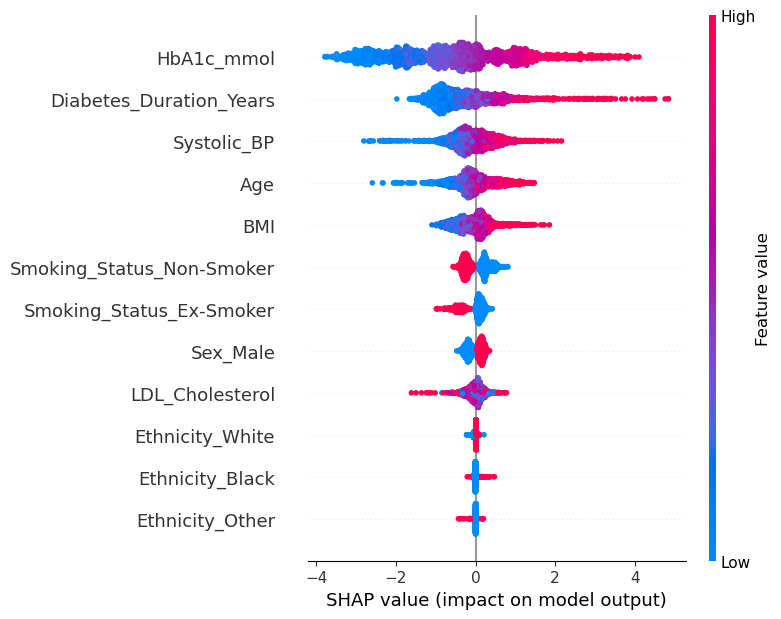

<Figure size 640x480 with 0 Axes>

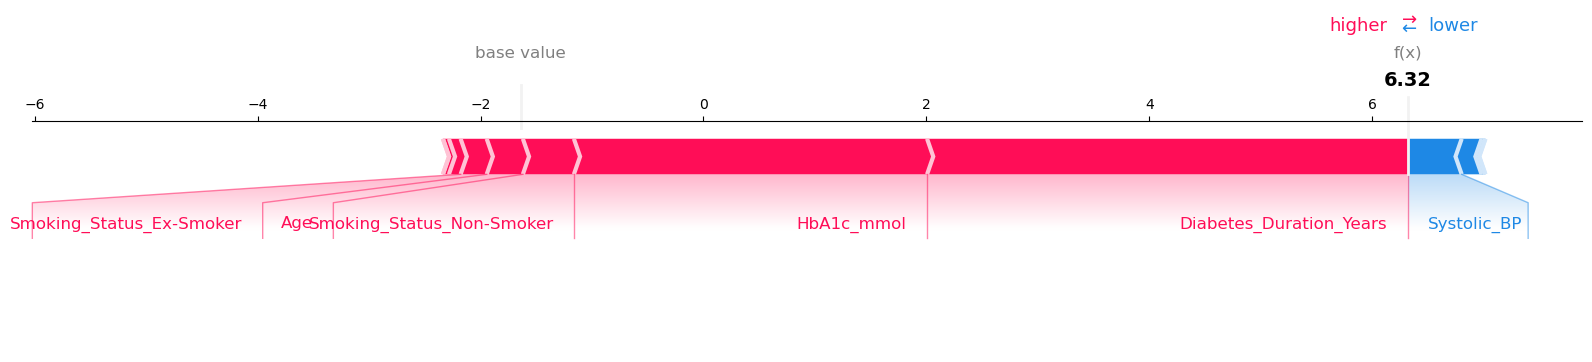

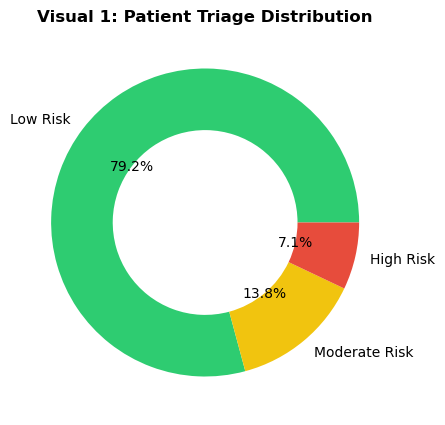

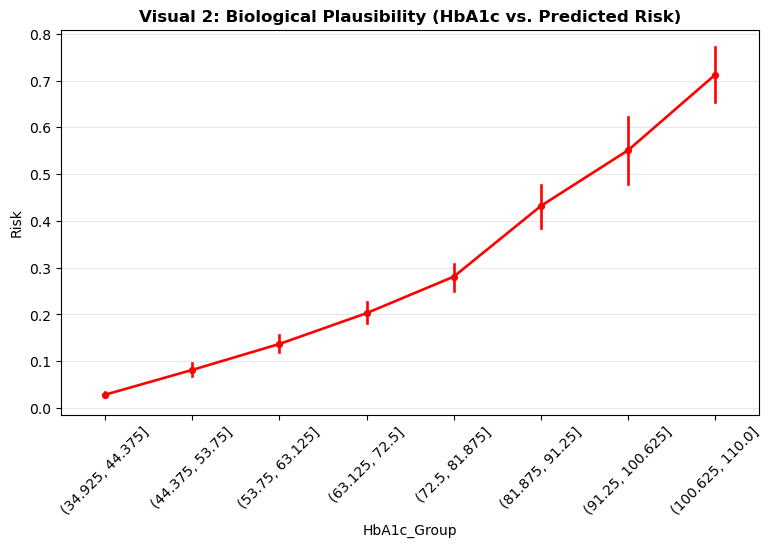

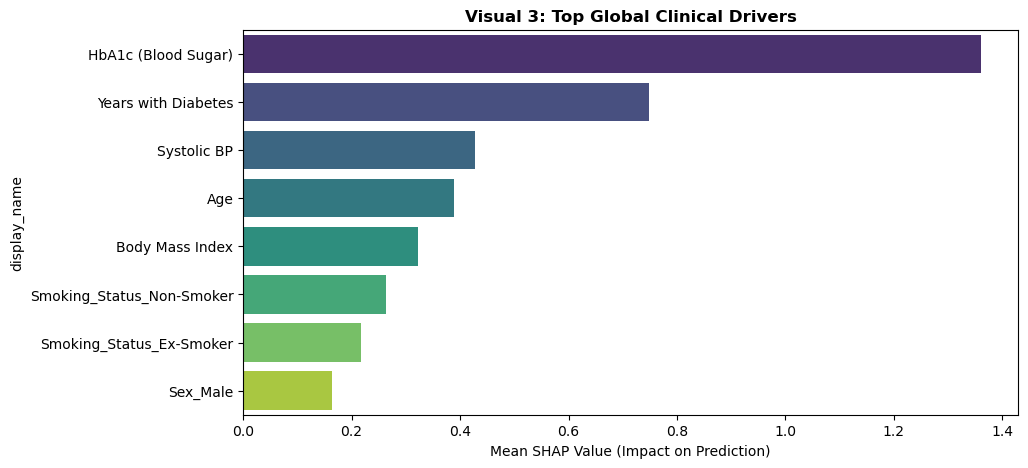

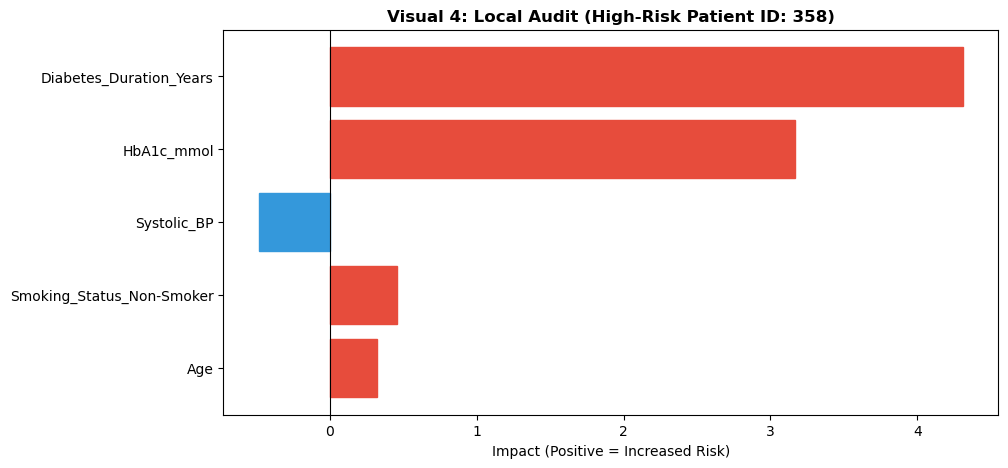

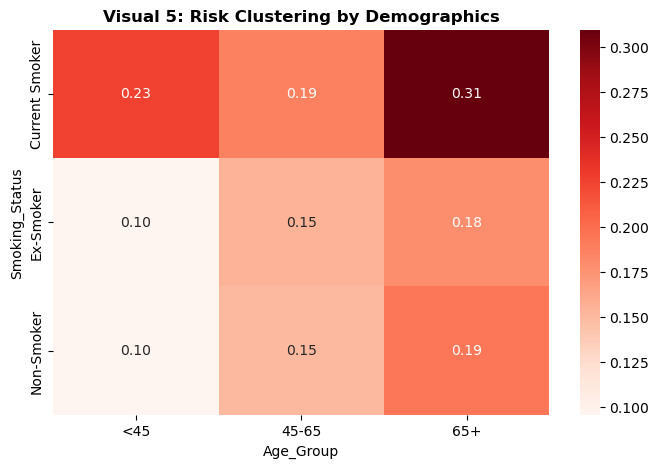

In [10]:
import warnings

warnings.filterwarnings('ignore') # Clean output for dissertation

# --- 1. DATA PREP ---
try:
    # Use the champion model to get probabilities
    y_probs = champion_xgb.predict_proba(X_test)[:, 1]
    
    # Extract components for SHAP
    model_internal = champion_xgb.named_steps['classifier']
    preprocessor = champion_xgb.named_steps['preprocessor']
    transformed_X_test = preprocessor.transform(X_test)
    
    # Get clinical feature names
    cat_features = preprocessor.named_transformers_['cat'].get_feature_names_out().tolist()
    all_feature_names = num_cols + cat_features
    
    # Dictionary for clean labels in the dissertation
    clean_map = {
        'HbA1c_mmol': 'HbA1c (Blood Sugar)',
        'BMI': 'Body Mass Index',
        'Systolic_BP': 'Systolic BP',
        'Diabetes_Duration_Years': 'Years with Diabetes',
        'Age': 'Age'
    }
except NameError as e:
    print(f"ERROR: Missing variables. Ensure 'champion_xgb' and 'X_test' exist. Details: {e}")

# --- 2. VISUALIZATION SUITE ---

# Visual 1: Risk Triage (Donut)
try:
    plt.figure(figsize=(7, 5))
    risk_labels = ['Low Risk', 'Moderate Risk', 'High Risk']
    risk_cats = pd.cut(y_probs, bins=[0, 0.3, 0.7, 1.0], labels=risk_labels)
    counts = risk_cats.value_counts().reindex(risk_labels)
    plt.pie(counts, labels=counts.index, autopct='%1.1f%%', colors=['#2ecc71', '#f1c40f', '#e74c3c'], wedgeprops={'width': 0.4})
    plt.title('Visual 1: Patient Triage Distribution', fontweight='bold')
    plt.show()
except Exception as e: print(f"Plot 1 Failed: {e}")

# Visual 2: HbA1c Tipping Point (FIXED LINEPLOT)
try:
    plt.figure(figsize=(9, 5))
    temp_df = X_test.copy()
    temp_df['Risk'] = y_probs
    # Convert bins to strings to avoid the TypeError
    temp_df['HbA1c_Group'] = pd.cut(temp_df['HbA1c_mmol'], bins=8).astype(str)
    
    # Sort the dataframe so the x-axis is in order
    temp_df = temp_df.sort_values('HbA1c_mmol')
    
    sns.pointplot(data=temp_df, x='HbA1c_Group', y='Risk', color='red', scale=0.7)
    plt.title('Visual 2: Biological Plausibility (HbA1c vs. Predicted Risk)', fontweight='bold')
    plt.xticks(rotation=45)
    plt.grid(axis='y', alpha=0.3)
    plt.show()
except Exception as e: print(f"Plot 2 Failed: {e}")

# Visual 3: Global Feature Importance (SHAP)
try:
    explainer = shap.TreeExplainer(model_internal)
    shap_values = explainer.shap_values(transformed_X_test)
    
    # Correctly handle SHAP values for binary classification
    if isinstance(shap_values, list):
        s_vals = np.abs(shap_values[1]).mean(0)
    else:
        s_vals = np.abs(shap_values).mean(0)
        
    feat_imp = pd.DataFrame({'feat': all_feature_names, 'imp': s_vals})
    feat_imp['display_name'] = feat_imp['feat'].map(lambda x: clean_map.get(x, x))
    feat_imp = feat_imp.sort_values('imp', ascending=False).head(8)
    
    plt.figure(figsize=(10, 5))
    sns.barplot(data=feat_imp, x='imp', y='display_name', palette='viridis')
    plt.title('Visual 3: Top Global Clinical Drivers', fontweight='bold')
    plt.xlabel('Mean SHAP Value (Impact on Prediction)')
    plt.show()
except Exception as e: print(f"Plot 3 Failed: {e}")

# Visual 4: Local Audit (Single Patient Decision)
try:
    high_risk_idx = np.argmax(y_probs)
    # Get values for the most high-risk patient
    if isinstance(shap_values, list):
        p_shap = shap_values[1][high_risk_idx]
    else:
        p_shap = shap_values[high_risk_idx]
        
    top_5_idx = np.argsort(np.abs(p_shap))[-5:]
    
    plt.figure(figsize=(10, 5))
    bars = plt.barh([all_feature_names[i] for i in top_5_idx], [p_shap[i] for i in top_5_idx])
    for i, bar in enumerate(bars):
        bar.set_color('#e74c3c' if p_shap[top_5_idx[i]] > 0 else '#3498db')
        
    plt.axvline(0, color='black', linewidth=0.8)
    plt.title(f'Visual 4: Local Audit (High-Risk Patient ID: {high_risk_idx})', fontweight='bold')
    plt.xlabel('Impact (Positive = Increased Risk)')
    plt.show()
except Exception as e: print(f"Plot 4 Failed: {e}")

# Visual 5: Complication Risk Heatmap (Demographics)
try:
    plt.figure(figsize=(8, 5))
    temp_df['Age_Group'] = pd.cut(temp_df['Age'], bins=[0, 45, 65, 100], labels=['<45', '45-65', '65+'])
    # Check if Smoking_Status column exists (might be one-hot encoded)
    smoke_col = 'Smoking_Status' if 'Smoking_Status' in temp_df.columns else 'Smoking_Status_Current Smoker'
    
    pivot = temp_df.pivot_table(index=smoke_col, columns='Age_Group', values='Risk', aggfunc='mean')
    sns.heatmap(pivot, annot=True, cmap='Reds', fmt='.2f')
    plt.title('Visual 5: Risk Clustering by Demographics', fontweight='bold')
    plt.show()
except Exception as e: print(f"Plot 5 Failed: {e}")

In [11]:
from sklearn.metrics import recall_score, confusion_matrix
import numpy as np

def calculate_clinical_metrics(model_obj, X_data, y_true, label="Model"):
    """
    Calculates Specificity and Recall (Sensitivity) with robust error handling.
    """
    try:
        # Get predictions
        y_pred = model_obj.predict(X_data)
        
        # Calculate Recall (Sensitivity)
        recall = recall_score(y_true, y_pred, zero_division=0)
        
        # Robust Confusion Matrix Unpacking (forces 2x2 even if a class is missing)
        cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
        tn, fp, fn, tp = cm.ravel()
        
        # Safety checks for division by zero
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
        fnr = fn / (fn + tp) if (fn + tp) > 0 else 0
        
        print(f"--- {label} Clinical Metrics ---")
        print(f"Recall (Sensitivity): {recall:.4f}")
        print(f"Specificity:         {specificity:.4f}")
        print(f"False Negative Rate:  {fnr:.4f} (Safety Critical)")
        print("-" * 30)
        
        return {
            "Recall": recall,
            "Specificity": specificity,
            "FNR": fnr
        }
    except Exception as e:
        print(f"Skipping {label}: {e}")
        return None

# --- ASSIGN MODELS ---
# We use a try-except block to find your models regardless of which cell was run last.
xgb_model_to_use = None
lr_model_to_use = None

# Attempt to find XGBoost (Trying 'best_xgb' or 'model')
try:
    xgb_model_to_use = best_xgb
except NameError:
    try:
        xgb_model_to_use = model
    except NameError:
        print("Error: Could not find XGBoost model (tried 'best_xgb' and 'model')")

# Attempt to find Logistic Regression (Using your confirmed name 'challenger_lr')
try:
    lr_model_to_use = challenger_lr
except NameError:
    print("Error: Could not find Logistic Regression model (tried 'challenger_lr')")

# --- EXECUTE CALCULATIONS ---
if 'X_test' in locals() and 'y_test' in locals():
    xgb_results = None
    lr_results = None

    if xgb_model_to_use:
        xgb_results = calculate_clinical_metrics(xgb_model_to_use, X_test, y_test, label="Champion (XGBoost)")
    
    if lr_model_to_use:
        lr_results = calculate_clinical_metrics(lr_model_to_use, X_test, y_test, label="Challenger (LR)")

    # --- DISSERTATION SUMMARY TABLE ---
    if xgb_results or lr_results:
        print("\n" + "="*45)
        print("FINAL CLINICAL COMPARISON (DISSERTATION READY)")
        print("="*45)
        print(f"{'Metric':<20} | {'LR (Challenger)':<15} | {'XGB (Champion)':<15}")
        print("-" * 55)
        
        def get_val(res, key):
            return f"{res[key]:.4f}" if res else "N/A"

        print(f"{'Recall (Sens.)':<20} | {get_val(lr_results, 'Recall'):<15} | {get_val(xgb_results, 'Recall'):<15}")
        print(f"{'Specificity':<20} | {get_val(lr_results, 'Specificity'):<15} | {get_val(xgb_results, 'Specificity'):<15}")
        print(f"{'False Neg Rate':<20} | {get_val(lr_results, 'FNR'):<15} | {get_val(xgb_results, 'FNR'):<15}")
else:
    print("CRITICAL: X_test or y_test not found in memory. Please run your data splitting cell first.")

Error: Could not find XGBoost model (tried 'best_xgb' and 'model')
--- Challenger (LR) Clinical Metrics ---
Recall (Sensitivity): 0.4489
Specificity:         0.9588
False Negative Rate:  0.5511 (Safety Critical)
------------------------------

FINAL CLINICAL COMPARISON (DISSERTATION READY)
Metric               | LR (Challenger) | XGB (Champion) 
-------------------------------------------------------
Recall (Sens.)       | 0.4489          | N/A            
Specificity          | 0.9588          | N/A            
False Neg Rate       | 0.5511          | N/A            
